<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Limpieza_Dataset_Titanic_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

# Cargar el dataset del Titanic
df = sns.load_dataset('titanic')

In [2]:
# Paso 1: Exploración inicial
print("Dimensiones del dataset:", df.shape)
print("Primeras filas:")
display(df.head())
print("\n\nInformación general:")
display(df.info())
print("\n\nValores faltantes por columna:")
display(df.isnull().sum())

Dimensiones del dataset: (891, 15)
Primeras filas:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True




Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None



Valores faltantes por columna:


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


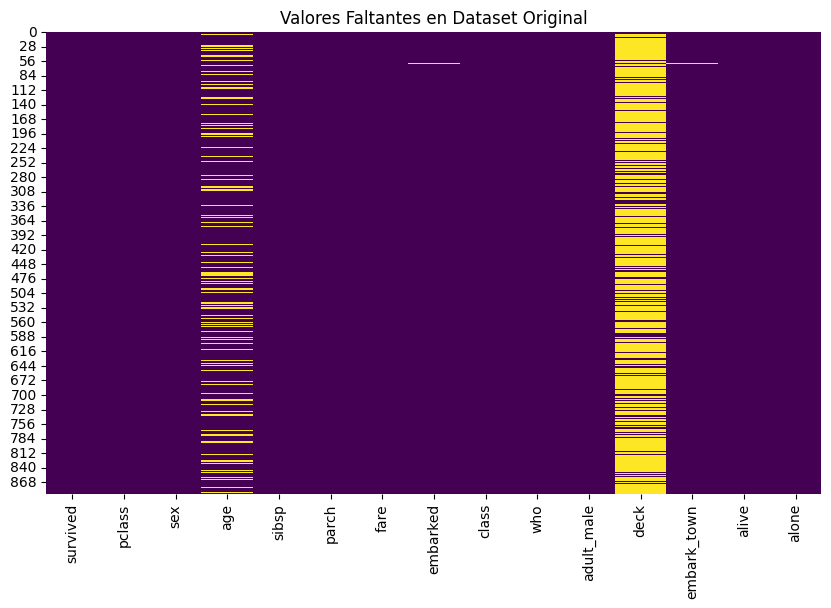

In [4]:

import matplotlib.pyplot as plt
import seaborn as sns

# Crear una copia del dataset original para comparación
df_original = sns.load_dataset('titanic')
# Gráfico 1: Heatmap de valores faltantes (antes de limpieza)
plt.figure(figsize=(10, 6))
sns.heatmap(df_original.isnull(), cbar=False, cmap='viridis')
plt.title('Valores Faltantes en Dataset Original')
plt.show()

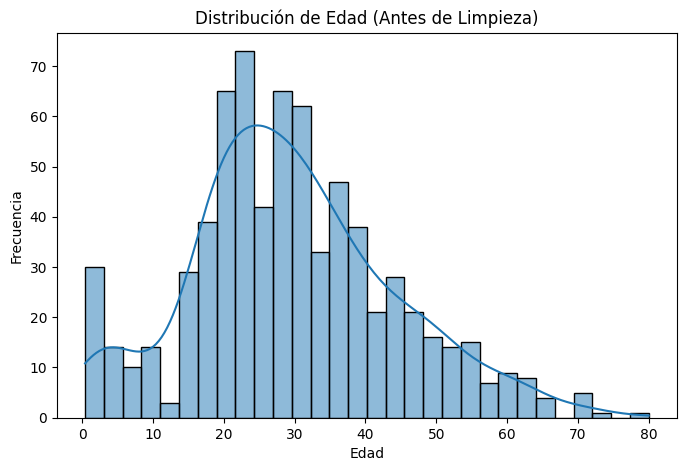

In [5]:
# Gráfico 2: Histograma de 'age' (antes de limpieza)
plt.figure(figsize=(8, 5))
sns.histplot(df_original['age'], bins=30, kde=True)
plt.title('Distribución de Edad (Antes de Limpieza)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

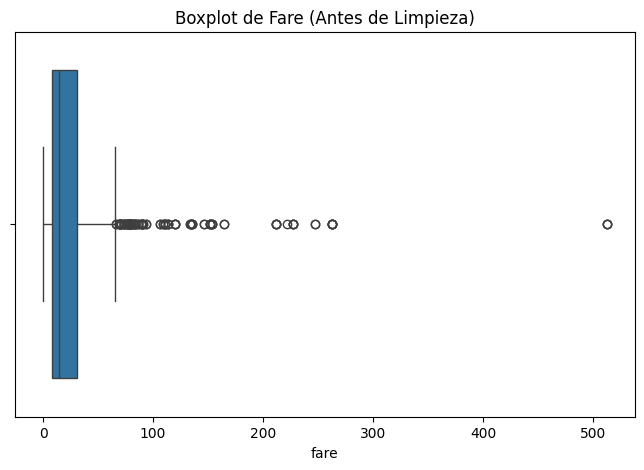

In [ ]:
# Gráfico 3: Boxplot de 'fare' (antes de limpieza, para outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_original['fare'])
plt.title('Boxplot de Fare (Antes de Limpieza)')
plt.show()

In [6]:
# Paso 2: Manejar valores faltantes
# Imputar 'age' con la mediana
df['age'] = df['age'].fillna(df['age'].median())
# Imputar 'embarked' con el valor más frecuente
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
# Eliminar columna 'deck' por muchos valores faltantes
df.drop('deck', axis=1, inplace=True)

In [ ]:
# Paso 3: Exploración
print("Dimensiones del dataset:", df.shape)
print("Primeras filas:")
display(df.head())
print("\n\nInformación general:")
display(df.info())
print("\n\nValores faltantes por columna:")
display(df.isnull().sum())

Dimensiones del dataset: (891, 14)
Primeras filas:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True




Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


None



Valores faltantes por columna:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [7]:
# Paso 4: Eliminar duplicados (asignación directa)
df = df.drop_duplicates()

In [8]:
# Paso 5: Normalizar columnas categóricas (ej. 'sex' y 'embarked')
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

In [9]:
# Paso 5: Verificar el dataset limpio
print("Dataset después de limpieza:")
display(df.head())
print("\n\nValores faltantes restantes:")
display(df.isnull().sum())
print("Dimensiones finales:", df.shape)

Dataset después de limpieza:


,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,False,True
1,1,1,1,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,False,False
2,1,3,1,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,False,True
3,1,1,1,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,False,True
4,0,3,0,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,False,True




Valores faltantes restantes:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
class,0
who,0
adult_male,0


Dimensiones finales: (775, 15)


In [13]:
print("\n\nInformación general:")
display(df.info())



Información general:
<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     775 non-null    int64   
 1   pclass       775 non-null    int64   
 2   sex          775 non-null    int64   
 3   age          775 non-null    float64 
 4   sibsp        775 non-null    int64   
 5   parch        775 non-null    int64   
 6   fare         775 non-null    float64 
 7   class        775 non-null    category
 8   who          775 non-null    object  
 9   adult_male   775 non-null    bool    
 10  embark_town  773 non-null    object  
 11  alive        775 non-null    object  
 12  alone        775 non-null    bool    
 13  embarked_Q   775 non-null    bool    
 14  embarked_S   775 non-null    bool    
dtypes: bool(4), category(1), float64(2), int64(5), object(3)
memory usage: 70.5+ KB


None

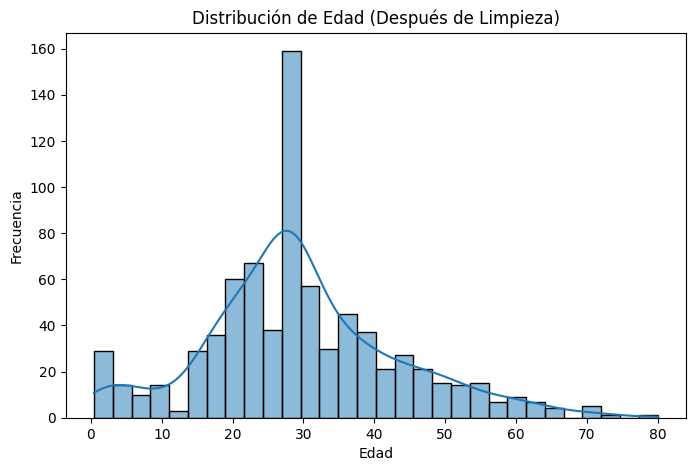

In [12]:
# Gráfico 4: Histograma de 'age' limpio
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribución de Edad (Después de Limpieza)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

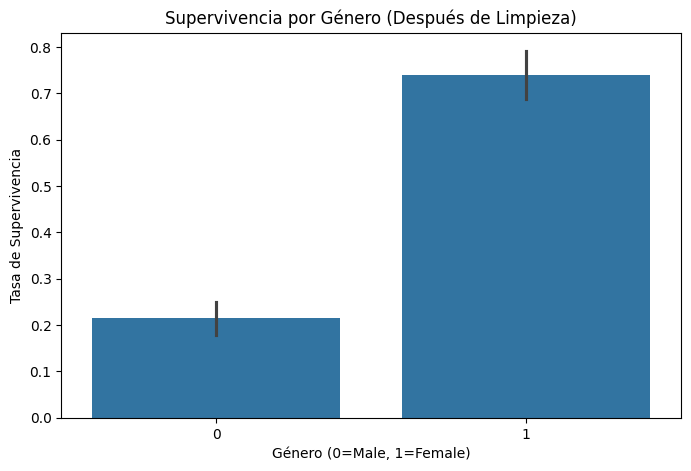

In [11]:
# Gráfico 5: Gráfico de barras de supervivencia por género
plt.figure(figsize=(8, 5))
sns.barplot(x='sex', y='survived', data=df)
plt.title('Supervivencia por Género (Después de Limpieza)')
plt.xlabel('Género (0=Male, 1=Female)')
plt.ylabel('Tasa de Supervivencia')
plt.show()

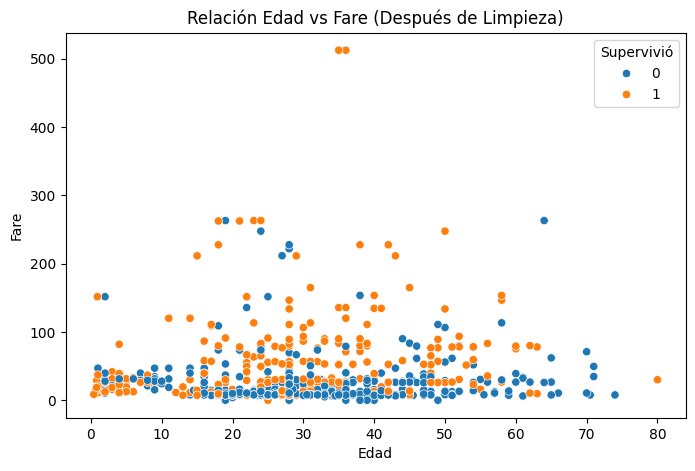

In [10]:
# Gráfico 6: Scatterplot de 'age' vs 'fare' (después de limpieza)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title('Relación Edad vs Fare (Después de Limpieza)')
plt.xlabel('Edad')
plt.ylabel('Fare')
plt.legend(title='Supervivió')
plt.show()